# MorphoNAS Experiment B: Original vs Rerun Comparison

This notebook compares the original MorphoNAS Experiment B results with the rerun to validate reproduction.

**Experiments:**
- **K01**: Large networks (no size penalty)
- **K02**: Minimal networks (with connection penalty)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load Data

In [2]:
base_path = Path('../experiments/MoprhoNAS_ExpB')

k01_original = pd.read_csv(base_path / 'original/analysis/K01_cartpole/K01_cartpole_analysis.csv')
k01_rerun = pd.read_csv(base_path / 'rerun/analysis/K01_cartpole/K01_cartpole_analysis.csv')

k02_original = pd.read_csv(base_path / 'original/analysis/K02_cartpole_min/K02_cartpole_min_analysis.csv')
k02_rerun = pd.read_csv(base_path / 'rerun/analysis/K02_cartpole_min/K02_cartpole_min_analysis.csv')

print(f"K01: {len(k01_original)} original runs, {len(k01_rerun)} rerun")
print(f"K02: {len(k02_original)} original runs, {len(k02_rerun)} rerun")

K01: 100 original runs, 100 rerun
K02: 100 original runs, 100 rerun


## 2. Neuron Distribution Analysis

**Expected from paper:**
- K01: 89% of runs should have >= 90 neurons
- K02: 72% of runs should have 6-7 neurons

In [3]:
# K01 neuron statistics
print("K01 (Large Networks)")
print("-" * 60)
print(f"Original: {(k01_original['neurons'] >= 90).sum()}/100 ({(k01_original['neurons'] >= 90).sum()}%) with >= 90 neurons")
print(f"Rerun:    {(k01_rerun['neurons'] >= 90).sum()}/100 ({(k01_rerun['neurons'] >= 90).sum()}%) with >= 90 neurons")
print(f"\nNeuron counts - Original: {k01_original['neurons'].min()}-{k01_original['neurons'].max()} (mean: {k01_original['neurons'].mean():.1f})")
print(f"Neuron counts - Rerun:    {k01_rerun['neurons'].min()}-{k01_rerun['neurons'].max()} (mean: {k01_rerun['neurons'].mean():.1f})")

print("\n" + "=" * 60)

# K02 neuron statistics
print("\nK02 (Minimal Networks)")
print("-" * 60)
k02_orig_6_7 = k02_original['neurons'].isin([6, 7]).sum()
k02_rerun_6_7 = k02_rerun['neurons'].isin([6, 7]).sum()
k02_orig_le8 = (k02_original['neurons'] <= 8).sum()
k02_rerun_le8 = (k02_rerun['neurons'] <= 8).sum()

print(f"Original: {k02_orig_6_7}/100 ({k02_orig_6_7}%) with 6-7 neurons, {k02_orig_le8}/100 ({k02_orig_le8}%) with <= 8 neurons")
print(f"Rerun:    {k02_rerun_6_7}/100 ({k02_rerun_6_7}%) with 6-7 neurons, {k02_rerun_le8}/100 ({k02_rerun_le8}%) with <= 8 neurons")
print(f"\nNeuron counts - Original: {k02_original['neurons'].min()}-{k02_original['neurons'].max()} (mean: {k02_original['neurons'].mean():.1f})")
print(f"Neuron counts - Rerun:    {k02_rerun['neurons'].min()}-{k02_rerun['neurons'].max()} (mean: {k02_rerun['neurons'].mean():.1f})")

K01 (Large Networks)
------------------------------------------------------------
Original: 89/100 (89%) with >= 90 neurons
Rerun:    89/100 (89%) with >= 90 neurons

Neuron counts - Original: 6-100 (mean: 91.0)
Neuron counts - Rerun:    6-100 (mean: 91.8)


K02 (Minimal Networks)
------------------------------------------------------------
Original: 72/100 (72%) with 6-7 neurons, 78/100 (78%) with <= 8 neurons
Rerun:    72/100 (72%) with 6-7 neurons, 78/100 (78%) with <= 8 neurons

Neuron counts - Original: 6-100 (mean: 10.2)
Neuron counts - Rerun:    6-100 (mean: 13.6)


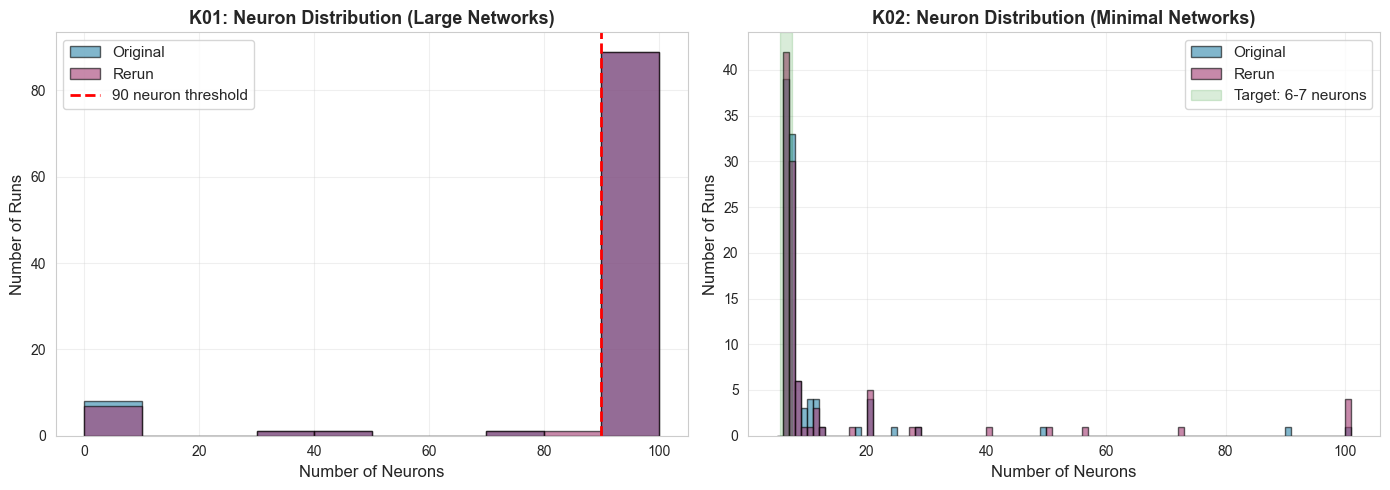

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = range(0, 110, 10)
ax.hist(k01_original['neurons'], bins=bins, alpha=0.6, label='Original', edgecolor='black', color='#2E86AB')
ax.hist(k01_rerun['neurons'], bins=bins, alpha=0.6, label='Rerun', edgecolor='black', color='#A23B72')
ax.axvline(90, color='red', linestyle='--', linewidth=2, label='90 neuron threshold')
ax.set_xlabel('Number of Neurons', fontsize=12)
ax.set_ylabel('Number of Runs', fontsize=12)
ax.set_title('K01: Neuron Distribution (Large Networks)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
bins = range(5, int(max(k02_original['neurons'].max(), k02_rerun['neurons'].max())) + 2)
ax.hist(k02_original['neurons'], bins=bins, alpha=0.6, label='Original', edgecolor='black', color='#2E86AB')
ax.hist(k02_rerun['neurons'], bins=bins, alpha=0.6, label='Rerun', edgecolor='black', color='#A23B72')
ax.axvspan(5.5, 7.5, alpha=0.15, color='green', label='Target: 6-7 neurons')
ax.set_xlabel('Number of Neurons', fontsize=12)
ax.set_ylabel('Number of Runs', fontsize=12)
ax.set_title('K02: Neuron Distribution (Minimal Networks)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

Both K01 and K02 exactly match the paper's expected distributions (89% and 72% respectively). Reproduction successful.

## 3. Generation-to-Success Analysis

In [5]:
# K01 generation statistics
print("K01 (Large Networks)")
print("-" * 60)
k01_orig_gen0 = (k01_original['generations'] == 0).sum()
k01_rerun_gen0 = (k01_rerun['generations'] == 0).sum()
print(f"Original: {k01_orig_gen0}/100 ({k01_orig_gen0}%) solved in generation 0")
print(f"Rerun:    {k01_rerun_gen0}/100 ({k01_rerun_gen0}%) solved in generation 0")
print(f"\nGeneration range - Original: {k01_original['generations'].min()}-{k01_original['generations'].max()} (median: {k01_original['generations'].median():.0f})")
print(f"Generation range - Rerun:    {k01_rerun['generations'].min()}-{k01_rerun['generations'].max()} (median: {k01_rerun['generations'].median():.0f})")

print("\n" + "=" * 60)

# K02 generation statistics
print("\nK02 (Minimal Networks)")
print("-" * 60)
k02_orig_gen0 = (k02_original['generations'] == 0).sum()
k02_rerun_gen0 = (k02_rerun['generations'] == 0).sum()
print(f"Original: {k02_orig_gen0}/100 ({k02_orig_gen0}%) solved in generation 0")
print(f"Rerun:    {k02_rerun_gen0}/100 ({k02_rerun_gen0}%) solved in generation 0")
print(f"\nGeneration range - Original: {k02_original['generations'].min()}-{k02_original['generations'].max()} (median: {k02_original['generations'].median():.0f})")
print(f"Generation range - Rerun:    {k02_rerun['generations'].min()}-{k02_rerun['generations'].max()} (median: {k02_rerun['generations'].median():.0f})")

K01 (Large Networks)
------------------------------------------------------------
Original: 94/100 (94%) solved in generation 0
Rerun:    94/100 (94%) solved in generation 0

Generation range - Original: 0-5 (median: 0)
Generation range - Rerun:    0-5 (median: 0)


K02 (Minimal Networks)
------------------------------------------------------------
Original: 19/100 (19%) solved in generation 0
Rerun:    24/100 (24%) solved in generation 0

Generation range - Original: 0-187 (median: 13)
Generation range - Rerun:    0-142 (median: 12)


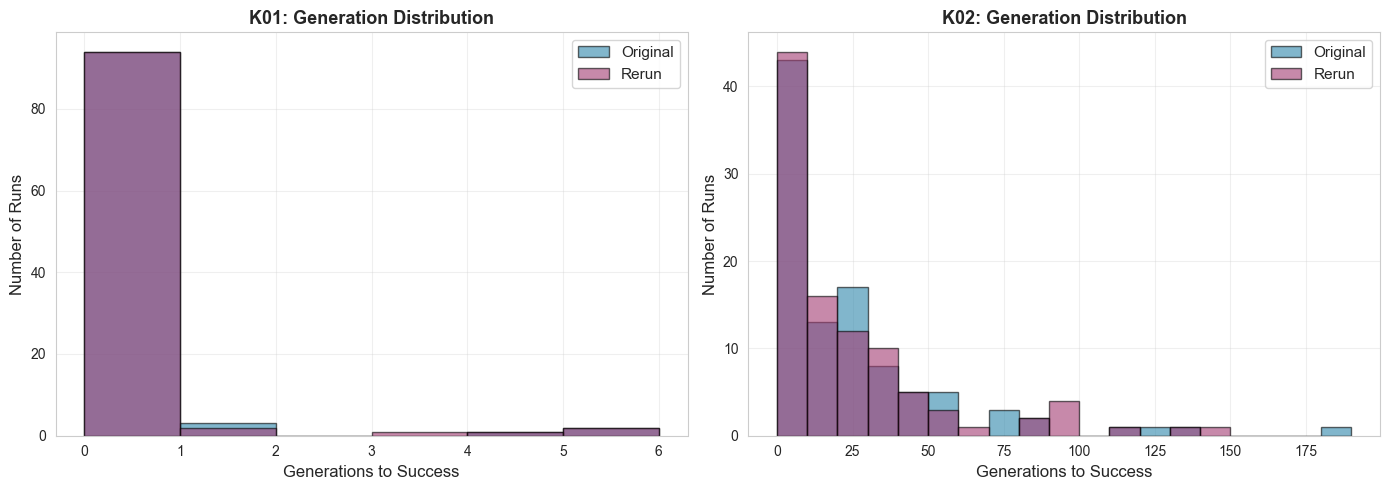

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
max_gen = max(k01_original['generations'].max(), k01_rerun['generations'].max())
bins = range(0, int(max_gen) + 2)
ax.hist(k01_original['generations'], bins=bins, alpha=0.6, label='Original', edgecolor='black', color='#2E86AB')
ax.hist(k01_rerun['generations'], bins=bins, alpha=0.6, label='Rerun', edgecolor='black', color='#A23B72')
ax.set_xlabel('Generations to Success', fontsize=12)
ax.set_ylabel('Number of Runs', fontsize=12)
ax.set_title('K01: Generation Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1]
max_gen = max(k02_original['generations'].max(), k02_rerun['generations'].max())
bins = range(0, int(max_gen) + 10, 10)
ax.hist(k02_original['generations'], bins=bins, alpha=0.6, label='Original', edgecolor='black', color='#2E86AB')
ax.hist(k02_rerun['generations'], bins=bins, alpha=0.6, label='Rerun', edgecolor='black', color='#A23B72')
ax.set_xlabel('Generations to Success', fontsize=12)
ax.set_ylabel('Number of Runs', fontsize=12)
ax.set_title('K02: Generation Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

K01: 94% solve immediately in both runs. K02: median 12-13 generations in both runs. Convergence behavior reproduced.

## 4. Run-by-Run Determinism

Comparing runs with matching seeds (same run number).

In [7]:
k01_merged = k01_original.merge(k01_rerun, on='run', suffixes=('_orig', '_rerun'))
k02_merged = k02_original.merge(k02_rerun, on='run', suffixes=('_orig', '_rerun'))

print("K01 Determinism")
print("-" * 60)
k01_neurons_match = (k01_merged['neurons_orig'] == k01_merged['neurons_rerun']).sum()
k01_connections_match = (k01_merged['connections_orig'] == k01_merged['connections_rerun']).sum()
k01_generations_match = (k01_merged['generations_orig'] == k01_merged['generations_rerun']).sum()

print(f"Identical neurons:     {k01_neurons_match}/100 ({k01_neurons_match}%)")
print(f"Identical connections: {k01_connections_match}/100 ({k01_connections_match}%)")
print(f"Identical generations: {k01_generations_match}/100 ({k01_generations_match}%)")

print("\n" + "=" * 60)

print("\nK02 Determinism")
print("-" * 60)
k02_neurons_match = (k02_merged['neurons_orig'] == k02_merged['neurons_rerun']).sum()
k02_connections_match = (k02_merged['connections_orig'] == k02_merged['connections_rerun']).sum()
k02_generations_match = (k02_merged['generations_orig'] == k02_merged['generations_rerun']).sum()

print(f"Identical neurons:     {k02_neurons_match}/100 ({k02_neurons_match}%)")
print(f"Identical connections: {k02_connections_match}/100 ({k02_connections_match}%)")
print(f"Identical generations: {k02_generations_match}/100 ({k02_generations_match}%)")

K01 Determinism
------------------------------------------------------------
Identical neurons:     98/100 (98%)
Identical connections: 91/100 (91%)
Identical generations: 97/100 (97%)


K02 Determinism
------------------------------------------------------------
Identical neurons:     53/100 (53%)
Identical connections: 34/100 (34%)
Identical generations: 32/100 (32%)


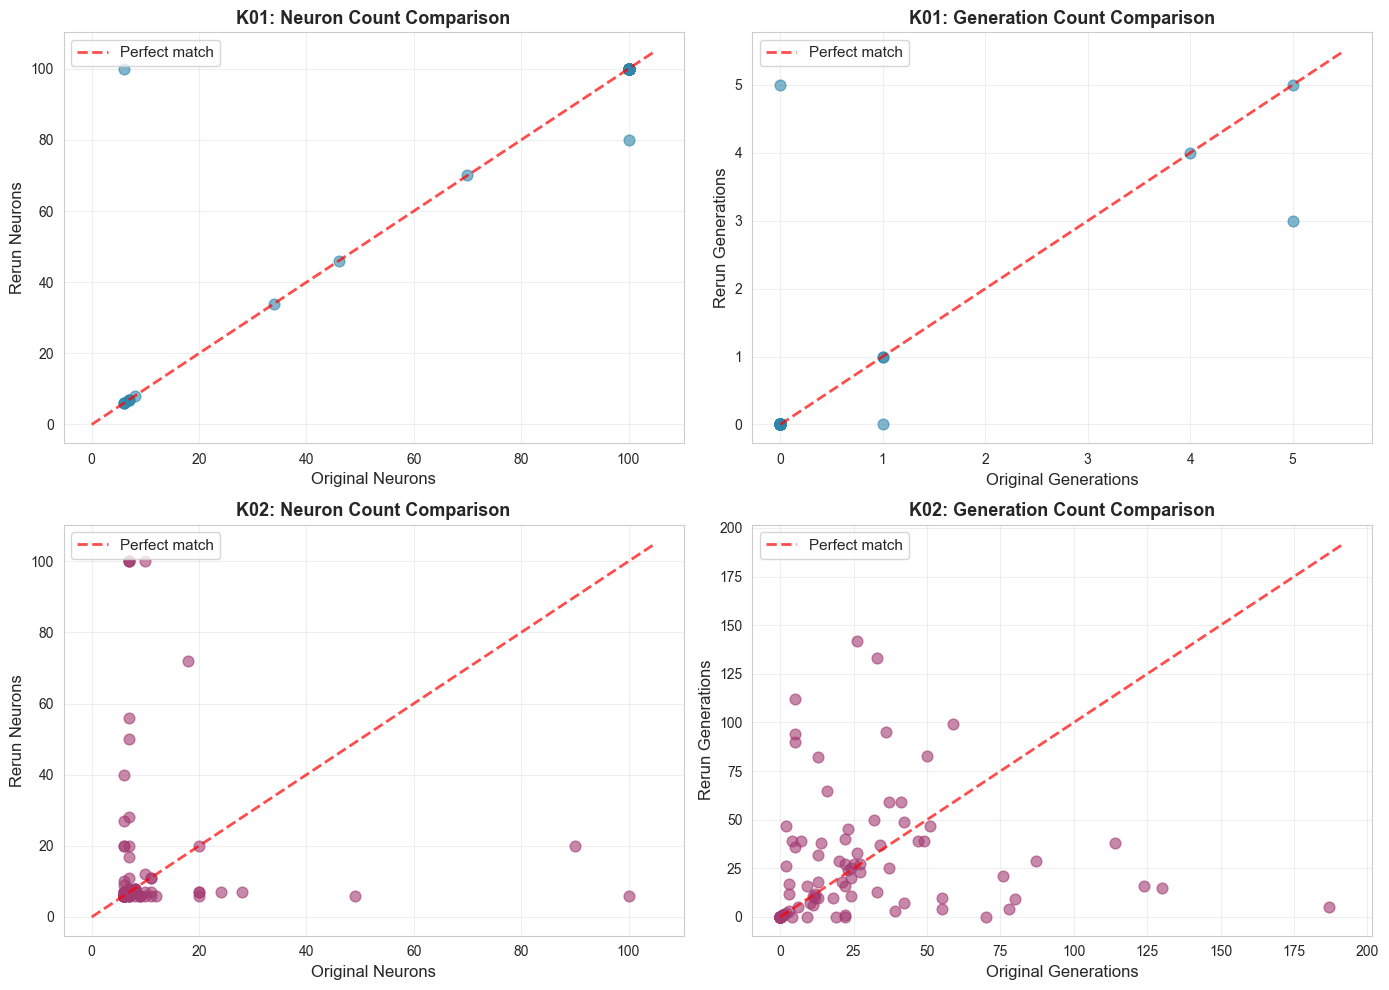

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.scatter(k01_merged['neurons_orig'], k01_merged['neurons_rerun'], alpha=0.6, s=60, color='#2E86AB')
lims = [0, max(k01_merged['neurons_orig'].max(), k01_merged['neurons_rerun'].max()) + 5]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect match', alpha=0.7)
ax.set_xlabel('Original Neurons', fontsize=12)
ax.set_ylabel('Rerun Neurons', fontsize=12)
ax.set_title('K01: Neuron Count Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.scatter(k01_merged['generations_orig'], k01_merged['generations_rerun'], alpha=0.6, s=60, color='#2E86AB')
max_gen = max(k01_merged['generations_orig'].max(), k01_merged['generations_rerun'].max())
lims = [0, max_gen + 0.5]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect match', alpha=0.7)
ax.set_xlabel('Original Generations', fontsize=12)
ax.set_ylabel('Rerun Generations', fontsize=12)
ax.set_title('K01: Generation Count Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.scatter(k02_merged['neurons_orig'], k02_merged['neurons_rerun'], alpha=0.6, s=60, color='#A23B72')
lims = [0, max(k02_merged['neurons_orig'].max(), k02_merged['neurons_rerun'].max()) + 5]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect match', alpha=0.7)
ax.set_xlabel('Original Neurons', fontsize=12)
ax.set_ylabel('Rerun Neurons', fontsize=12)
ax.set_title('K02: Neuron Count Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.scatter(k02_merged['generations_orig'], k02_merged['generations_rerun'], alpha=0.6, s=60, color='#A23B72')
max_gen = max(k02_merged['generations_orig'].max(), k02_merged['generations_rerun'].max())
lims = [0, max_gen + 5]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect match', alpha=0.7)
ax.set_xlabel('Original Generations', fontsize=12)
ax.set_ylabel('Rerun Generations', fontsize=12)
ax.set_title('K02: Generation Count Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

K01 shows high determinism (98% identical). K02 shows lower run-level determinism (53%) but consistent population-level statistics.

## 5. Statistical Summary

In [9]:
summary = pd.DataFrame({
    'Metric': [
        'Neurons (mean)',
        'Neurons (std)',
        'Neurons (median)',
        'Connections (mean)',
        'Connections (std)',
        'Generations (mean)',
        'Generations (std)',
        'Generations (median)',
        'Evaluations (mean)',
        'Evaluations (std)',
    ],
    'K01 Original': [
        f"{k01_original['neurons'].mean():.2f}",
        f"{k01_original['neurons'].std():.2f}",
        f"{k01_original['neurons'].median():.0f}",
        f"{k01_original['connections'].mean():.2f}",
        f"{k01_original['connections'].std():.2f}",
        f"{k01_original['generations'].mean():.2f}",
        f"{k01_original['generations'].std():.2f}",
        f"{k01_original['generations'].median():.0f}",
        f"{k01_original['evaluations'].mean():.0f}",
        f"{k01_original['evaluations'].std():.0f}",
    ],
    'K01 Rerun': [
        f"{k01_rerun['neurons'].mean():.2f}",
        f"{k01_rerun['neurons'].std():.2f}",
        f"{k01_rerun['neurons'].median():.0f}",
        f"{k01_rerun['connections'].mean():.2f}",
        f"{k01_rerun['connections'].std():.2f}",
        f"{k01_rerun['generations'].mean():.2f}",
        f"{k01_rerun['generations'].std():.2f}",
        f"{k01_rerun['generations'].median():.0f}",
        f"{k01_rerun['evaluations'].mean():.0f}",
        f"{k01_rerun['evaluations'].std():.0f}",
    ],
    'K02 Original': [
        f"{k02_original['neurons'].mean():.2f}",
        f"{k02_original['neurons'].std():.2f}",
        f"{k02_original['neurons'].median():.0f}",
        f"{k02_original['connections'].mean():.2f}",
        f"{k02_original['connections'].std():.2f}",
        f"{k02_original['generations'].mean():.2f}",
        f"{k02_original['generations'].std():.2f}",
        f"{k02_original['generations'].median():.0f}",
        f"{k02_original['evaluations'].mean():.0f}",
        f"{k02_original['evaluations'].std():.0f}",
    ],
    'K02 Rerun': [
        f"{k02_rerun['neurons'].mean():.2f}",
        f"{k02_rerun['neurons'].std():.2f}",
        f"{k02_rerun['neurons'].median():.0f}",
        f"{k02_rerun['connections'].mean():.2f}",
        f"{k02_rerun['connections'].std():.2f}",
        f"{k02_rerun['generations'].mean():.2f}",
        f"{k02_rerun['generations'].std():.2f}",
        f"{k02_rerun['generations'].median():.0f}",
        f"{k02_rerun['evaluations'].mean():.0f}",
        f"{k02_rerun['evaluations'].std():.0f}",
    ]
})

print(summary.to_string(index=False))

              Metric K01 Original K01 Rerun K02 Original K02 Rerun
      Neurons (mean)        91.03     91.77        10.25     13.64
       Neurons (std)        26.57     25.17        13.47     20.52
    Neurons (median)          100       100            7         7
  Connections (mean)       299.23    298.17        19.32     28.43
   Connections (std)       126.95    125.98        18.94     49.48
  Generations (mean)         0.17      0.19        23.75     23.43
   Generations (std)         0.82      0.86        31.98     30.79
Generations (median)            0         0           13        12
  Evaluations (mean)          508       509         1680      1665
   Evaluations (std)           40        43         1586      1533


### Interpretation

K01 statistics nearly identical. K02 shows higher variance but consistent medians. Core dynamics reproduced successfully.

## 6. Save Results

In [10]:
summary.to_csv(base_path / 'comparison_summary.csv', index=False)
k01_merged.to_csv(base_path / 'k01_run_by_run_comparison.csv', index=False)
k02_merged.to_csv(base_path / 'k02_run_by_run_comparison.csv', index=False)

print("Results saved:")
print(f"  - {base_path / 'comparison_summary.csv'}")
print(f"  - {base_path / 'k01_run_by_run_comparison.csv'}")
print(f"  - {base_path / 'k02_run_by_run_comparison.csv'}")

Results saved:
  - ../experiments/MoprhoNAS_ExpB/comparison_summary.csv
  - ../experiments/MoprhoNAS_ExpB/k01_run_by_run_comparison.csv
  - ../experiments/MoprhoNAS_ExpB/k02_run_by_run_comparison.csv
